# 'This is going to ruin the tour'
Justin Timberlake famously said 'This is going to ruin the tour' after being arrested from driving while intoxicated. While the moment created fun and giggles, drunk driving should not be encouraged and has devastating consequences. In Philadelphia, thousands of crashes are reported each year where at least one driver was reported to be under alcohol influence.

In [31]:
# Set up
import pandas as pd
import geopandas as gpd
import os
import matplotlib.pyplot as plt
import matplotlib as mpl
import datetime as dt

# Load Processed Data
fatal_alc = pd.read_csv('data/philly_fatal_alc.csv', low_memory=False)

# Load Philly Boundary Map
philly_gdf = gpd.read_file('data/philadelphia_zip_boundaries.geojson')

Thousands of crashes happen each year in Philly, but they might happen for a myriad of reasons. People could be running late and be impulsive. Breaks can fail. Nevertheless, thousands of crashes each year could be prevented by not driving while intoxicated. Using data from the Pennsylvania Department of Transport, we will inspect the cases of alcohol related crashes.

In [32]:
fatal_alc_gpd = gpd.GeoDataFrame(fatal_alc, geometry=gpd.points_from_xy(x=fatal_alc['DEC_LONGITUDE'], y=fatal_alc['DEC_LATITUDE']))
fatal_alc_gpd.crs='epsg:4326'

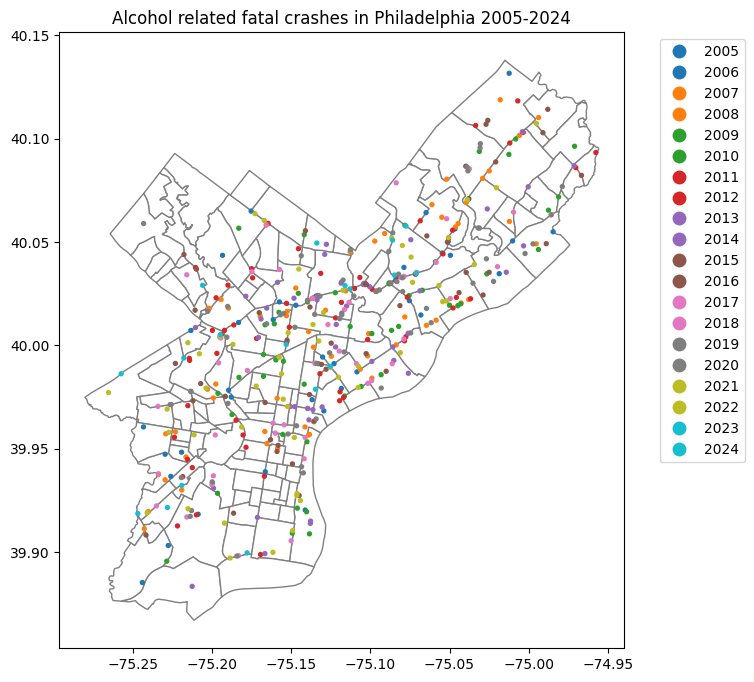

In [33]:
base=philly_gdf.plot(color='white', 
                     edgecolor='gray', figsize=(8,8))
fatal_alc_gpd.plot(ax=base,
                          markersize=8, 
                          column='CRASH_YEAR', 
                          categorical=True, 
                          legend=True,
                          legend_kwds={'bbox_to_anchor': (1.05, 1), 'loc': 'upper left'}
                         )
plt.title('Alcohol related fatal crashes in Philadelphia 2005-2024')
plt.show()

As observed in the map, Broad Street and the Roosevelt Boulevard are the main road where these fatalities happen. But since our data set is from 2005 to 2024, we can inspect the trends in fatal crashes that are alcohol related.

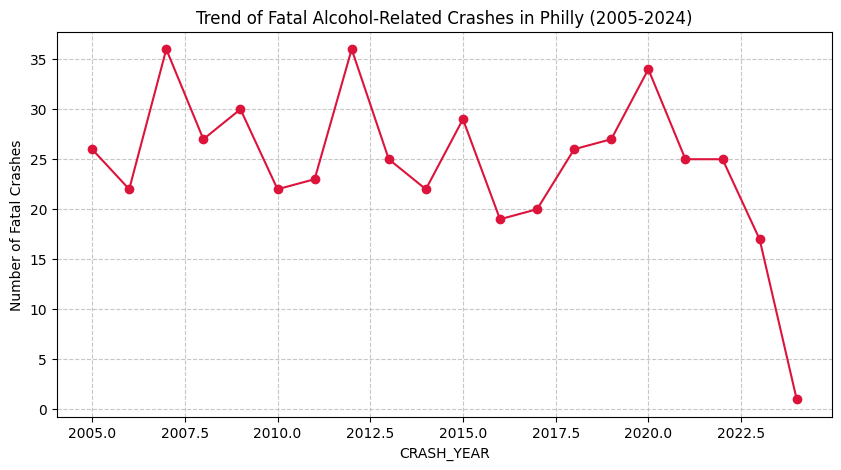

In [34]:
# Group by Year
yearly_trends = fatal_alc_gpd.groupby('CRASH_YEAR').size()

# Plotting the trend
plt.figure(figsize=(10, 5))
yearly_trends.plot(kind='line', marker='o', color='crimson')
plt.title('Trend of Fatal Alcohol-Related Crashes in Philly (2005-2024)')
plt.ylabel('Number of Fatal Crashes')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

While it seems like fatal crashes have been going down for the past few years, it is worth noting that the data for 2024 only includes the first couple of months. In general, there are at least 20 alcohol related fatal crashes per year in Philadelphia, with a few exceptions. 

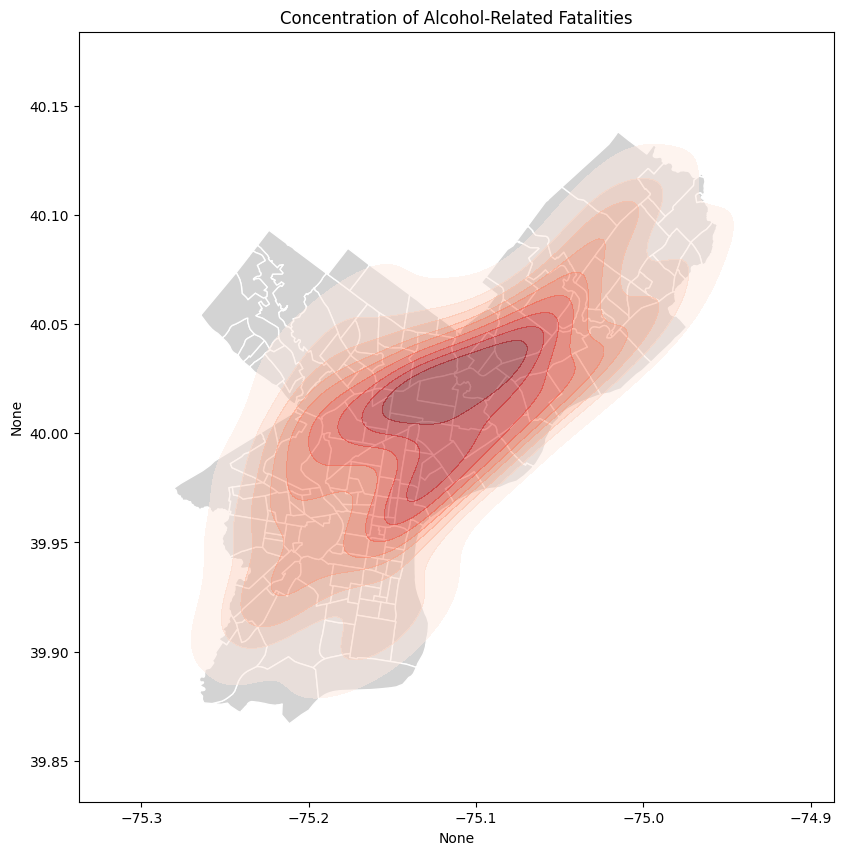

In [35]:
import seaborn as sns

# Plotting the density of crashes
fig, ax = plt.subplots(figsize=(10, 10))
philly_gdf.plot(ax=ax, color='lightgrey', edgecolor='white')
sns.kdeplot(
    x=fatal_alc_gpd.geometry.x, 
    y=fatal_alc_gpd.geometry.y, 
    fill=True, cmap='Reds', alpha=0.5, ax=ax
)
ax.set_title('Concentration of Alcohol-Related Fatalities')
plt.show()

As seen by the density plot, Roosevelt Boulervard does have the highest density of alcohol related crashes. Possible measures to reduce this numbers might be to implement sobriety checkpoints at the entrances to Roosevelt Boulevard.